In [1]:
import os, math, warnings, gc, random
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_everything(SEED)

# Tự động phát hiện GPU nếu có
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [2]:
# ====== CẤU HÌNH ======
DATA_PATH = r"C:\Users\ADMIN\Desktop\Dữ Liệu\IDS2018-v2\NF-CSE-CIC-IDS2018-V2.parquet"
LABEL_COL   = 'Label'
N_PCA       = 20
N_BINS      = 32
BATCH_SIZE  = 1024
NUM_WORKERS = 0
EPOCHS      = 8          # Tăng số epoch
LR          = 3e-4        # Giảm LR ban đầu — sẽ có warmup
D_MODEL     = 128         # ✅ Tăng tham số: 128 → 256
N_HEADS     = 8
N_PERSIST   = 4
LMM_HIDDEN  = 128        # ✅ Tăng tham số: 128 → 256
OUTLIER_TH  = 3.0
PRE_BATCH   = 50000
SWA_WINDOW  = 16
LMM_LAYERS  = 3           # ✅ Tăng số lớp LTM: 2 → 3
HEAD_DROPOUT = 0.2        # Tăng dropout nhẹ để tránh overfitting khi model lớn hơn
LMM_DROPOUT  = 0.15

# --- Warmup scheduler ---
WARMUP_EPOCHS = 2         # ✅ Số epoch warmup để ổn định gradient ban đầu

# --- Focal Loss gamma ---
FOCAL_GAMMA = 2.0         # ✅ Focal Loss: tập trung vào các mẫu khó

# Sẽ được cập nhật sau khi load data
N_APT_PHASES = 15

## 1. Load parquet + xử lý cột constant & log transform

In [3]:
df = pd.read_parquet(DATA_PATH)
print('Raw shape:', df.shape)

std_series = df.std(numeric_only=True)
const_cols = std_series[std_series == 0].index.tolist()
print('Cột số constant:', const_cols)

if 'SRC_TO_DST_SECOND_BYTES' in df.columns:
    df['SRC_TO_DST_SECOND_BYTES_LOG'] = np.log1p(df['SRC_TO_DST_SECOND_BYTES'])
    df = df.drop(columns=['SRC_TO_DST_SECOND_BYTES'])
    print('✅ Đã log-transform SRC_TO_DST_SECOND_BYTES')

# ====== ĐA NHÃN: dùng cột Attack ======
LABEL_MULTI = 'Attack' if 'Attack' in df.columns else 'Label'
print(f'Dùng cột nhãn: {LABEL_MULTI}')

drop_cols = [c for c in ['Label', 'Attack'] + const_cols if c in df.columns]
numerical_columns = [c for c in df.columns
                     if c not in drop_cols and np.issubdtype(df[c].dtype, np.number)]

X = df[numerical_columns].copy()
attack_raw = df[LABEL_MULTI].astype(str).fillna('Benign').values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(attack_raw).astype(np.int64)
CLASS_NAMES = list(label_encoder.classes_)
N_APT_PHASES = len(CLASS_NAMES)

print(f'X shape: {X.shape} | y shape: {y.shape}')
print(f'Số lớp: {len(CLASS_NAMES)}')
print('Danh sách nhãn:')
for i, name in enumerate(CLASS_NAMES):
    cnt = int((y == i).sum())
    print(f'  {i:2d} - {name}: {cnt:,}')

Raw shape: (17129715, 43)
Cột số constant: ['FTP_COMMAND_RET_CODE']
✅ Đã log-transform SRC_TO_DST_SECOND_BYTES
Dùng cột nhãn: Attack
X shape: (17129715, 40) | y shape: (17129715,)
Số lớp: 15
Danh sách nhãn:
   0 - Benign: 15,101,685
   1 - Bot: 28,033
   2 - Brute Force -Web: 2,143
   3 - Brute Force -XSS: 927
   4 - DDOS attack-HOIC: 1,066,881
   5 - DDOS attack-LOIC-UDP: 2,112
   6 - DDoS attacks-LOIC-HTTP: 207,078
   7 - DoS attacks-GoldenEye: 27,723
   8 - DoS attacks-Hulk: 432,648
   9 - DoS attacks-SlowHTTPTest: 14,116
  10 - DoS attacks-Slowloris: 9,512
  11 - FTP-BruteForce: 25,933
  12 - Infilteration: 115,513
  13 - SQL Injection: 432
  14 - SSH-Bruteforce: 94,979


## 2. Split train / val / test (stratified)

In [4]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=2/3, stratify=y_tmp, random_state=SEED)
print(f'Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_te.shape}')
del X, X_tmp, y_tmp, df; gc.collect()

Train: (11990800, 40) | Val: (1712971, 40) | Test: (3425944, 40)


20

## 3. Robust preprocessing theo batch (NaN / Inf / Outlier)

In [5]:
def robust_clean(X_tr, X_val, X_te, batch=50_000, th=3.0):
    """Xử lý NaN / Inf / Outlier theo batch."""
    print('🔄 Robust cleaning...')
    
    if hasattr(X_tr, 'values'): X_tr = X_tr.values
    if hasattr(X_val, 'values'): X_val = X_val.values
    if hasattr(X_te, 'values'): X_te = X_te.values
        
    X_tr  = X_tr.astype(np.float32)
    X_val = X_val.astype(np.float32)
    X_te  = X_te.astype(np.float32)

    s = min(100_000, len(X_tr))
    idx = np.random.choice(len(X_tr), s, replace=False)
    med = np.nanmedian(X_tr[idx], axis=0)
    std = np.nanstd(X_tr[idx],    axis=0); std[std==0] = 1.0

    def clean(A):
        out = []
        for i in range(0, len(A), batch):
            B = A[i:i+batch].copy()
            B[np.isinf(B)] = np.nan
            for c in range(B.shape[1]):
                m = med[c]
                bad = np.isnan(B[:,c]) | (np.abs((B[:,c]-m)/std[c]) > th)
                B[bad, c] = m
            out.append(np.clip(B, -1e6, 1e6))
        return np.vstack(out)

    Xtr, Xva, Xte = clean(X_tr), clean(X_val), clean(X_te)
    print(f'  ✅ NaN={np.isnan(Xtr).any()} | Inf={np.isinf(Xtr).any()}')
    return Xtr, Xva, Xte


X_tr, X_val, X_te = robust_clean(X_tr, X_val, X_te, PRE_BATCH, OUTLIER_TH)

# PCA
nc = min(N_PCA, X_tr.shape[1])
pca = PCA(n_components=nc, random_state=SEED)
X_tr  = pca.fit_transform(X_tr)
X_val = pca.transform(X_val)
X_te  = pca.transform(X_te)
print(f'PCA: {nc} components | variance={pca.explained_variance_ratio_.sum()*100:.1f}%')

# StandardScaler
sc = StandardScaler()
X_tr  = sc.fit_transform(X_tr)
X_val = sc.transform(X_val)
X_te  = sc.transform(X_te)

# KBins tokenize
kbd = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
tok_tr  = kbd.fit_transform(X_tr).astype(np.int64)
tok_val = kbd.transform(X_val).astype(np.int64)
tok_te  = kbd.transform(X_te).astype(np.int64)

vocab = [int(max(tok_tr[:,i].max(), tok_val[:,i].max(), tok_te[:,i].max())) + 2
         for i in range(tok_tr.shape[1])]
SEQ_LEN = tok_tr.shape[1]
print(f'Token shape: {tok_tr.shape} | vocab sample: {vocab[:5]}')

🔄 Robust cleaning...
  ✅ NaN=False | Inf=False
PCA: 20 components | variance=100.0%
Token shape: (11990800, 20) | vocab sample: [33, 33, 33, 33, 33]


## 6. Dataset & DataLoader

In [6]:
class TokenDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).long()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

kw = dict(num_workers=0, pin_memory=False)
train_loader = DataLoader(TokenDS(tok_tr,  y_tr),  BATCH_SIZE, shuffle=True,  drop_last=True,  **kw)
val_loader   = DataLoader(TokenDS(tok_val, y_val), BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(TokenDS(tok_te,  y_te),  BATCH_SIZE, shuffle=False, **kw)
print(f'Batches — train:{len(train_loader)} | val:{len(val_loader)} | test:{len(test_loader)}')

Batches — train:11709 | val:1673 | test:3346


## 7. Kiến trúc Titan MAG (v2 — GELU + Pre-LN + Deep MLP Head)

In [7]:
# ============================================================
# ✅ KHAI BÁO FOCAL LOSS — xử lý mất cân bằng lớp cực đoan
# ============================================================
class FocalLoss(nn.Module):
    """
    Focal Loss: tự động giảm trọng số của các mẫu 'dễ đoán' (confidence cao)
    và ép mô hình tập trung học các mẫu khó (tấn công thiểu số).
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.weight    = weight
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # Tính CE loss theo từng mẫu (none reduction)
        ce_loss = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        # p_t = exp(-ce_loss)
        p_t = torch.exp(-ce_loss)
        # Focal factor: (1 - p_t)^gamma
        focal_loss = (1.0 - p_t) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


# ============================================================
# ✅ FEATURE EMBEDDING — không thay đổi, đã tốt
# ============================================================
class FeatureEmbedding(nn.Module):
    def __init__(self, vocab_sizes, d):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(v, d) for v in vocab_sizes])
        self.pos  = nn.Embedding(len(vocab_sizes), d)
        self.norm = nn.LayerNorm(d)
    def forward(self, x):
        B, L = x.shape
        h = torch.stack([self.embs[i](x[:,i]) for i in range(L)], dim=1)
        p = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        return self.norm(h + self.pos(p))


# ============================================================
# ✅ NEURAL LONG TERM MEMORY — nâng cấp với GELU + Pre-LN
# ============================================================
class NeuralLongTermMemory(nn.Module):
    """
    Bước 3+4 — LTM / LMM theo Section 3.1 của Titans.

    Cải tiến v2:
      ✅ Kích hoạt GELU thay ReLU — tránh dead neurons, hội tụ nhanh hơn
      ✅ Pre-LayerNorm (chuẩn hóa TRƯỚC khi đưa vào lớp Linear)
         → gradient lan truyền ổn định hơn qua nhiều lớp
      ✅ Tăng hidden dimension (d // 2 → d * 4 // 3) cho khả năng học cao hơn
    """
    def __init__(self, d, num_blocks=3, dropout=0.15):
        super().__init__()

        # === 1. Deep Residual Bottleneck MLP với GELU + Pre-LN ===
        hidden = d * 4 // 3  # ✅ Tăng hidden dimension từ d//2 lên d*4//3
        self.M_blocks = nn.ModuleList([
            nn.ModuleDict({
                'norm': nn.LayerNorm(d),           # ✅ Pre-LayerNorm: trước linear
                'fc1':  nn.Linear(d, hidden),
                'act':  nn.GELU(),                 # ✅ GELU thay ReLU
                'drop': nn.Dropout(dropout),
                'fc2':  nn.Linear(hidden, d),
            }) for _ in range(num_blocks)
        ])
        self.M_norm = nn.LayerNorm(d)

        # === 2. Test-time Learning Gates ===
        self.alpha = nn.Linear(d, 1)   # Forget gate
        self.eta   = nn.Linear(d, 1)   # Momentum
        self.theta = nn.Linear(d, 1)   # Learning rate

        # === 3. Attention Projections ===
        self.key   = nn.Linear(d, d)
        self.value = nn.Linear(d, d)
        self.query = nn.Linear(d, d)

        # === 4. Output Projection ===
        self.out_proj = nn.Linear(d, d)
        self.norm     = nn.LayerNorm(d)

    def _M(self, x):
        """Pre-LN Residual Bottleneck MLP forward."""
        for b in self.M_blocks:
            # ✅ Pre-LayerNorm: norm TRƯỚC linear (thay vì sau)
            h = b['norm'](x)                              # Pre-LN
            h = b['fc2'](b['drop'](b['act'](b['fc1'](h))))
            x = x + h                                     # Residual connection
        return self.M_norm(x)

    def forward(self, h):
        B, L, D = h.shape
        k = self.key(h);   v = self.value(h);   q = self.query(h)
        a = torch.sigmoid(self.alpha(h))
        e = torch.sigmoid(self.eta(h))
        t = torch.sigmoid(self.theta(h)) * 0.1
        Mt = torch.zeros(B, D, device=h.device)
        St = torch.zeros(B, D, device=h.device)
        outs = []
        for i in range(L):
            v_hat = self._M(k[:,i]) + Mt
            St = e[:,i]*St - t[:,i]*2*(v_hat - v[:,i])
            Mt = (1 - a[:,i])*Mt + St
            outs.append(self.out_proj(self._M(q[:,i]) + Mt))
        return self.norm(torch.stack(outs, dim=1))


# ============================================================
# ✅ SLIDING WINDOW ATTENTION — nâng cấp với Pre-LN
# ============================================================
class SlidingWindowAttention(nn.Module):
    """Bước 5 — SWA với Pre-LN Residual (thay Post-LN)."""
    def __init__(self, d, n_heads, window=16):
        super().__init__()
        self.attn   = nn.MultiheadAttention(d, n_heads, batch_first=True, dropout=0.1)
        self.norm   = nn.LayerNorm(d)   # ✅ Pre-LN
        self.window = window
    def forward(self, x):
        L   = x.size(1)
        idx = torch.arange(L, device=x.device)
        d   = idx.unsqueeze(0) - idx.unsqueeze(1)
        mask = (d > 0) | (d < -(self.window - 1))
        # ✅ Pre-LN: chuẩn hóa x TRƯỚC khi đưa vào attention
        h = self.norm(x)
        y, _ = self.attn(h, h, h, attn_mask=mask, need_weights=False)
        return x + y   # Residual connection


# ============================================================
# ✅ TITAN MAG v2 — Deep MLP Head + tăng tham số
# ============================================================
class TitanMAG(nn.Module):
    """
    Titan — Memory as a Gate (MAG) v2.

    Cải tiến:
      ✅ Tăng D_MODEL: 128 → 256 (tăng tham số)
      ✅ Tăng LMM_LAYERS: 2 → 3 (thêm lớp mạng perceptron)
      ✅ Deep MLP Head: 1 lớp ẩn → 2 lớp ẩn + GELU
      ✅ Pre-LayerNorm xuyên suốt kiến trúc
      ✅ GELU activation thay thế toàn bộ ReLU
    """
    def __init__(self, vocab_sizes, n_classes,
                 d=256, n_heads=8, n_persist=4, swa_window=16,
                 lmm_blocks=3, lmm_dropout=0.15, head_dropout=0.2):
        super().__init__()
        self.embed   = FeatureEmbedding(vocab_sizes, d)
        self.P       = nn.Parameter(torch.randn(1, n_persist, d) * 0.02)

        # Bước 3+4: SWA || LTM song song
        self.swa    = SlidingWindowAttention(d, n_heads, swa_window)
        self.lmm    = NeuralLongTermMemory(d, num_blocks=lmm_blocks, dropout=lmm_dropout)

        # Merge + Gate (Pre-LN)
        self.merge     = nn.Linear(d * 2, d)
        self.gate      = nn.Linear(d, d)
        self.gate_norm = nn.LayerNorm(d)

        # ✅ Deep MLP Head — 2 lớp ẩn với GELU thay vì 1 lớp ReLU
        self.head = nn.Sequential(
            nn.LayerNorm(d),                      # Pre-LN trước head
            nn.Linear(d, d * 2),                  # Mở rộng chiều
            nn.GELU(),                            # ✅ GELU
            nn.Dropout(head_dropout),
            nn.Linear(d * 2, d),                  # Thu hẹp lại — bottleneck
            nn.GELU(),                            # ✅ GELU thứ 2
            nn.Dropout(head_dropout / 2),
            nn.Linear(d, n_classes)               # Output projection
        )
        self.np = n_persist

    def forward(self, x):
        B = x.size(0)
        h = self.embed(x)                                    # (B, L, d)

        # Prepend persistent tokens
        xt = torch.cat([self.P.expand(B,-1,-1), h], dim=1)  # (B, P+L, d)

        # Bước 3+4: SWA || LTM deep MLP
        y_swa = self.swa(xt)                                 # (B, P+L, d)
        y_lmm = self.lmm(xt)                                 # (B, P+L, d)

        out = self.merge(torch.cat([y_swa, y_lmm], dim=-1))  # (B, P+L, d)
        out = self.gate_norm(out * torch.sigmoid(self.gate(xt)))  # Gating

        out = out[:, self.np:].mean(dim=1)                   # Pool, bỏ persistent
        return self.head(out)


model = TitanMAG(vocab, N_APT_PHASES,
                 d=D_MODEL, n_heads=N_HEADS, n_persist=N_PERSIST,
                 swa_window=SWA_WINDOW,
                 lmm_blocks=LMM_LAYERS, lmm_dropout=LMM_DROPOUT,
                 head_dropout=HEAD_DROPOUT).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'TitanMAG v2 (GELU + Pre-LN + Deep Head)')
print(f'Params: {total:,}')

TitanMAG v2 (GELU + Pre-LN + Deep Head)
Params: 471,056


## 8. Train (Focal Loss + Log-Smoothed Weights + LR Warmup)

In [8]:
def run_eval(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(DEVICE)).argmax(-1).cpu().numpy())
            trues.append(yb.numpy())
    p, t = np.concatenate(preds), np.concatenate(trues)
    return dict(
        acc  = accuracy_score(t, p),
        f1   = f1_score(t, p, average='weighted', zero_division=0),
        prec = precision_score(t, p, average='weighted', zero_division=0),
        rec  = recall_score(t, p, average='weighted', zero_division=0),
        pred = p, true = t
    )


# ✅ LOG-SMOOTHED CLASS WEIGHTS — giải quyết vấn đề gradient shock
# Vấn đề cũ: len(y_tr) / (N_APT_PHASES * class_counts) tạo ra trọng số chênh 35000x
# Giải pháp: dùng log1p để kìm hãm sự bùng nổ trọng số
class_counts = np.bincount(y_tr, minlength=N_APT_PHASES)
smoothed = np.log1p(class_counts.astype(np.float64))          # log-smooth
smoothed_weights = smoothed.max() / np.maximum(smoothed, 1e-6) # normalize
weights = torch.tensor(smoothed_weights, dtype=torch.float32, device=DEVICE)

print('Class weights (log-smoothed):')
for i, (n, w) in enumerate(zip(CLASS_NAMES, smoothed_weights)):
    print(f'  [{i:2d}] {n}: count={class_counts[i]:>10,} | weight={w:.3f}')

# ✅ FOCAL LOSS với log-smoothed weights (kết hợp 2 kỹ thuật)
criterion = FocalLoss(weight=weights, gamma=FOCAL_GAMMA)

# ✅ OPTIMIZER: AdamW với weight_decay mạnh hơn để regularize model lớn hơn
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)

# ✅ LR WARMUP + CosineAnnealingLR
# LinearLR: tăng tuyến tính từ LR/10 → LR trong WARMUP_EPOCHS đầu
# CosineAnnealingLR: giảm từ LR → 0 trong phần còn lại
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=LR * 0.01
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS]
)

print(f'\nModel Training (v2 — Focal Loss + Warmup Scheduler)')
print(f'Epochs={EPOCHS} | LR={LR} | Warmup={WARMUP_EPOCHS} epochs | Focal gamma={FOCAL_GAMMA}')
print('=' * 80)

history = []
best_f1 = 0.0
best_state = None

for ep in range(1, EPOCHS + 1):
    model.train()
    losses = []
    current_lr = optimizer.param_groups[0]['lr']
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    scheduler.step()

    m = run_eval(model, val_loader)
    avg_loss = np.mean(losses)
    history.append({'ep': ep, 'loss': avg_loss, **{k: m[k] for k in ['acc','f1','prec','rec']}})
    print(f'[Epoch {ep:2d}/{EPOCHS}] lr={current_lr:.2e} | loss={avg_loss:.4f} | acc={m["acc"]:.4f} | f1={m["f1"]:.4f} | prec={m["prec"]:.4f} | rec={m["rec"]:.4f}.')

    # ✅ Best model checkpoint
    if m['f1'] > best_f1:
        best_f1 = m['f1']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'  ↑ Best F1 updated: {best_f1:.4f}')

print(f'\n✅ Training complete! Best val F1 = {best_f1:.4f}')

# Load best weights
if best_state is not None:
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print('✅ Loaded best checkpoint.')

Class weights (log-smoothed):
  [ 0] Benign: count=10,571,179 | weight=1.000
  [ 1] Bot: count=    19,623 | weight=1.636
  [ 2] Brute Force -Web: count=     1,500 | weight=2.211
  [ 3] Brute Force -XSS: count=       649 | weight=2.497
  [ 4] DDOS attack-HOIC: count=   746,817 | weight=1.196
  [ 5] DDOS attack-LOIC-UDP: count=     1,478 | weight=2.216
  [ 6] DDoS attacks-LOIC-HTTP: count=   144,955 | weight=1.361
  [ 7] DoS attacks-GoldenEye: count=    19,406 | weight=1.638
  [ 8] DoS attacks-Hulk: count=   302,854 | weight=1.281
  [ 9] DoS attacks-SlowHTTPTest: count=     9,881 | weight=1.758
  [10] DoS attacks-Slowloris: count=     6,658 | weight=1.837
  [11] FTP-BruteForce: count=    18,153 | weight=1.649
  [12] Infilteration: count=    80,859 | weight=1.431
  [13] SQL Injection: count=       303 | weight=2.829
  [14] SSH-Bruteforce: count=    66,485 | weight=1.456

Model Training (v2 — Focal Loss + Warmup Scheduler)
Epochs=8 | LR=0.0003 | Warmup=2 epochs | Focal gamma=2.0
[Epoch  1/

## 9. Learning Curve

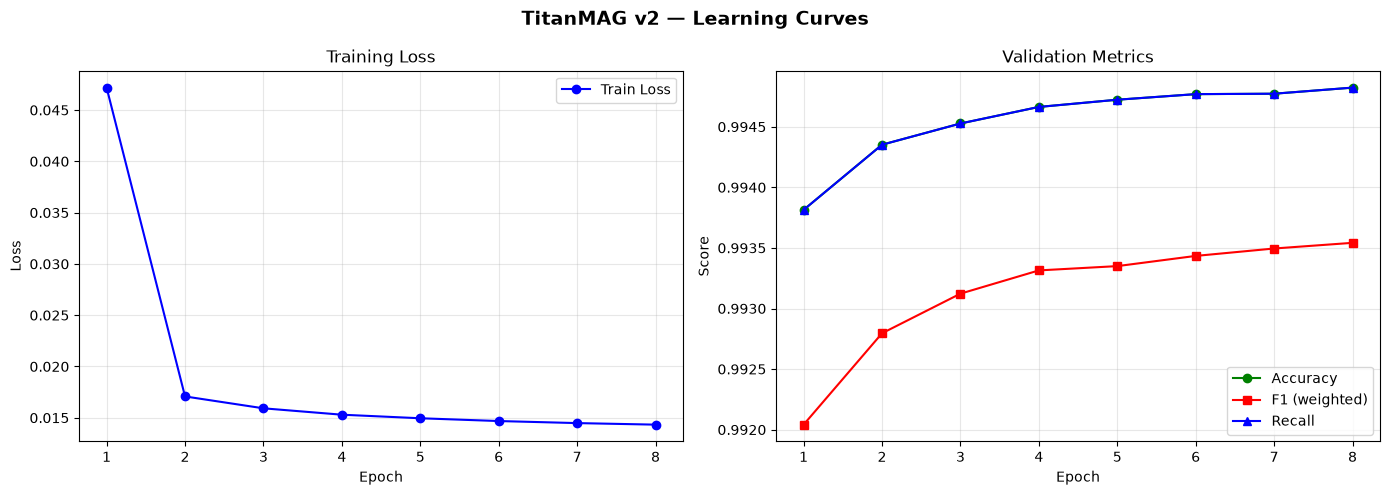

✅ Saved learning curves.


In [9]:
# Vẽ learning curve
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_df['ep'], hist_df['loss'], 'b-o', label='Train Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_df['ep'], hist_df['acc'],  'g-o', label='Accuracy')
axes[1].plot(hist_df['ep'], hist_df['f1'],   'r-s', label='F1 (weighted)')
axes[1].plot(hist_df['ep'], hist_df['rec'],  'b-^', label='Recall')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('TitanMAG v2 — Learning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved learning curves.')

## 10. Đánh giá trên tập TEST + Confusion Matrix


===== TEST METRICS (TitanMAG v2) =====
Accuracy        : 0.9948
F1  (weighted)  : 0.9935
F1  (macro)     : 0.7985
Precision (w)   : 0.9944
Recall    (w)   : 0.9948

                          precision    recall  f1-score   support

                  Benign       0.99      1.00      1.00   3020338
                     Bot       1.00      1.00      1.00      5607
        Brute Force -Web       0.83      0.13      0.22       429
        Brute Force -XSS       0.85      0.15      0.26       185
        DDOS attack-HOIC       1.00      1.00      1.00    213376
    DDOS attack-LOIC-UDP       0.99      0.99      0.99       422
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     41415
   DoS attacks-GoldenEye       0.99      0.99      0.99      5545
        DoS attacks-Hulk       1.00      1.00      1.00     86529
DoS attacks-SlowHTTPTest       1.00      1.00      1.00      2823
   DoS attacks-Slowloris       0.94      1.00      0.97      1903
          FTP-BruteForce       1.00      

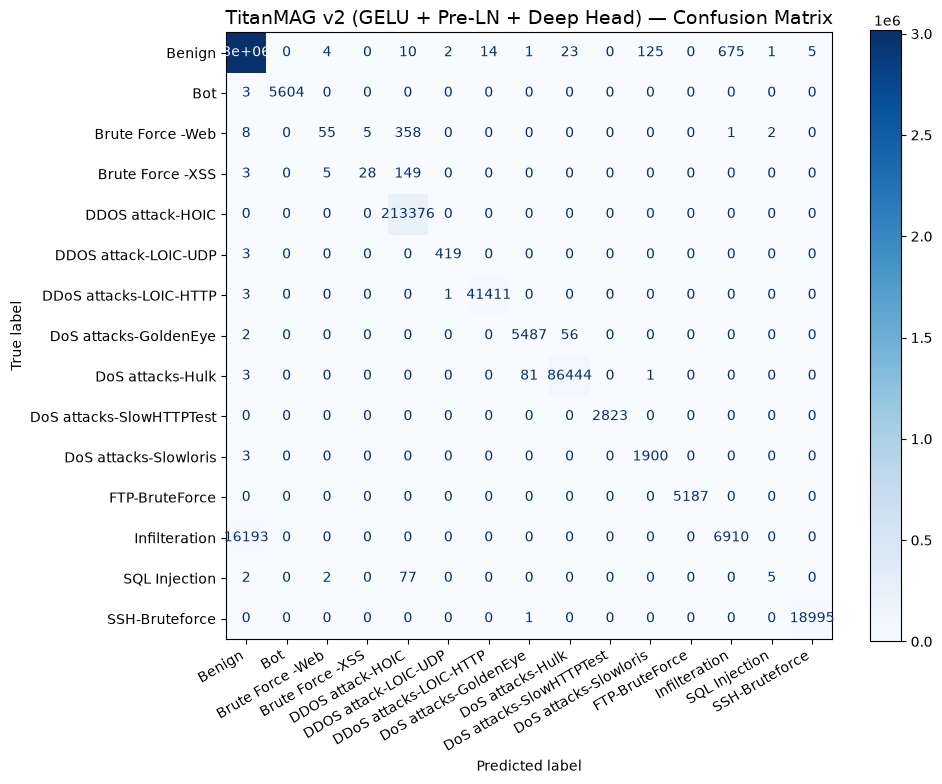

In [10]:
m = run_eval(model, test_loader)
APT_PHASE_NAMES = CLASS_NAMES

print('\n===== TEST METRICS (TitanMAG v2) =====')
print(f'Accuracy        : {m["acc"]:.4f}')
print(f'F1  (weighted)  : {m["f1"]:.4f}')
print(f'F1  (macro)     : {f1_score(m["true"], m["pred"], average="macro", zero_division=0):.4f}')
print(f'Precision (w)   : {m["prec"]:.4f}')
print(f'Recall    (w)   : {m["rec"]:.4f}')
print()
print(classification_report(m['true'], m['pred'],
                             target_names=APT_PHASE_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix(m['true'], m['pred']),
    display_labels=APT_PHASE_NAMES
).plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('TitanMAG v2 (GELU + Pre-LN + Deep Head) — Confusion Matrix', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150)
plt.show()